<a href="https://colab.research.google.com/github/taehi5/Esaa_YB/blob/4%EC%A3%BC%EC%B0%A8-%EA%B3%BC%EC%A0%9C/ESAA_YB_Week4_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 05. 데이터 전처리
1.  결손값은 허용 X  -> 고정된 다른 값으로 변환
- 평균값으로 보통 대체
- 대부분이 null -> drop

2. 문자열 인코딩
- 카레고리형 : 코드값으로 표현
- 텍스트형: 피처 벡터화 혹은 삭제


### 데이터 인코딩
1. 레이블 인코딩 : 카테고리 피처를 코드형 숫자 값으로 변환
- labelEncoder 클래스로 구현

In [1]:
from sklearn.preprocessing import LabelEncoder

items=['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

# LabelEncoder를 객체로 생성한 후, fit( )과 transform( )으로 레이블 인코딩 수행.
encoder = LabelEncoder()
encoder.fit(items)
labels = encoder.transform(items)
print('인코딩 변환값:', labels)

인코딩 변환값: [0 1 4 5 3 3 2 2]


데이터가 많으면 어떤 숫자 값으로 인코딩됐는지 직관적으로 알기 힘듦 -> `classes_`속성값으로 확인

In [2]:
print('인코딩 클래스:', encoder.classes_)

인코딩 클래스: ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


`inverse_transform()`이용해 디코딩 가능

In [3]:
print('디코딩 원본값:', encoder.inverse_transform([4, 5, 2, 0, 1, 1, 3, 3]))

디코딩 원본값: ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']


**레이블 인코딩의 문제점** : 변환된 숫자에 크고 작음의 의미가 생긴다.
  - 냉장고(1) < 믹서(2) → 일부 ML 알고리즘이 2에 가중치를 더 주거나 더 중요하게 인식할 수 있음
  - 실제로는 단순 코드일 뿐, 순서나 중요도의 의미가 없음

- 적용 범위
  - ❌ 선형 회귀 등 숫자 크기를 반영하는 알고리즘 → 예측 성능 저하 가능
  - ⭕ 트리 계열 알고리즘 → 숫자 크기를 반영하지 않으므로 문제없음

=>  **원-핫 인코딩(One-Hot Encoding)** 등장

2. 원-핫 인코딩(One-Hot Encoding): 피처 값의 유형(고유 값)마다 새로운 피처(칼럼)를 추가하고, 해당하는 칼럼에만 1, 나머지 칼럼에는 0을 표시하는 방식
 - 행 형태의 고유 값을 열 형태로 차원 변환하는 것

> 사이킷런 `OneHotEncoder` 사용 시 주의점
> 1) 입력값으로 2차원 데이터가 필요함
> 2) 변환 결과가 희소 행렬 이므로 `toarray()`로 밀집 행렬로 변환해야 함

In [4]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

items=['TV','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서']

# 2차원 ndarray로 변환합니다.
items = np.array(items).reshape(-1, 1)

# 원-핫 인코딩을 적용합니다.
oh_encoder = OneHotEncoder()
oh_encoder.fit(items)
oh_labels = oh_encoder.transform(items)

# OneHotEncoder로 변환한 결과는 희소행렬이므로 toarray()를 이용해 밀집 행렬로 변환.
print('원-핫 인코딩 데이터')
print(oh_labels.toarray())
print('원-핫 인코딩 데이터 차원')
print(oh_labels.shape)

원-핫 인코딩 데이터
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
원-핫 인코딩 데이터 차원
(8, 6)


`get_dummies()` api 이용

In [6]:
import pandas as pd

df = pd.DataFrame({'item':['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']
})
pd.get_dummies(df, dtype=int)

,item_TV,item_냉장고,item_믹서,item_선풍기,item_전자레인지,item_컴퓨터
0,1,0,0,0,0,0
1,0,1,0,0,0,0
2,0,0,0,0,1,0
3,0,0,0,0,0,1
4,0,0,0,1,0,0
5,0,0,0,1,0,0
6,0,0,1,0,0,0
7,0,0,1,0,0,0


### 피처 스케일링과 정규화

1. 피처 스케일링(feature scaling): 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업
  - 대표적인 방법: 표준화(Standardization), 정규화(Normalization)

A. 표준화 (Standardization): 각 피처를 평균 0, 분산 1인 가우시안 정규 분포 값으로 변환
- 원래 값에서 평균을 빼고 표준편차로 나눔

B. 정규화 (Normalization): 서로 다른 피처의 크기를 통일하기 위해 값을 최소 0 ~ 최대 1로 변환
- 원래 값에서 최솟값을 빼고 (최댓값 − 최솟값)으로 나눔
> 사이킷런 `Normalizer` (벡터 정규화)
> - 일반적인 정규화와 큰 개념은 같지만, 선형대수의 정규화 개념이 적용됨
> - 개별 벡터의 크기를 맞추기 위해, 각 값을 모든 피처 벡터의 크기로 나눔

C. StandardScaler: 표준화를 쉽게 지원하는 클래스 → 개별 피처를 평균 0, 분산 1인 값으로 변환
- 데이터를 가우시안 정규 분포 형태로 바꾸는 것은 일부 알고리즘에서 매우 중요함
- 사전에 표준화를 적용하면 예측 성능 향상에 도움이 됨

In [7]:
from sklearn.datasets import load_iris
import pandas as pd
# 붓꽃 데이터 세트를 로딩하고 DataFrame으로 변환합니다.
iris = load_iris()
iris_data = iris.data
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)

print('feature 들의 평균 값')
print(iris_df.mean())
print('\nfeature 들의 분산 값')
print(iris_df.var())

feature 들의 평균 값
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

feature 들의 분산 값
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


StandardScaler 이용해 한번에 표준화

In [8]:
from sklearn.preprocessing import StandardScaler

# StandardScaler객체 생성
scaler = StandardScaler()
# StandardScaler로 데이터 세트 변환. fit( )과 transform( ) 호출.
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

# transform( ) 시 스케일 변환된 데이터 세트가 NumPy ndarray로 반환돼 이를 DataFrame으로 변환
iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('feature 들의 평균 값')
print(iris_df_scaled.mean())
print('\nfeature 들의 분산 값')
print(iris_df_scaled.var())

feature 들의 평균 값
sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

feature 들의 분산 값
sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


D.  MinMaxScaler: 데이터 값을 0 ~ 1 사이의 범위로 변환
- 데이터 분포가 가우시안 분포가 아닐 경우 적용해 볼 수 있음

In [9]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler객체 생성
scaler = MinMaxScaler()
# MinMaxScaler로 데이터 세트 변환. fit()과 transform() 호출.
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

# transform() 시 스케일 변환된 데이터 세트가 NumPy ndarray로 반환돼 이를 DataFrame으로 변환
iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('feature들의 최솟값')
print(iris_df_scaled.min())
print('\nfeature들의 최댓값')
print(iris_df_scaled.max())

feature들의 최솟값
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

feature들의 최댓값
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


E. 학습 데이터와 테스트 데이터의 스케일링 변환 시 유의점

- Scaler 객체의 주요 메서드
  - `fit()`: 데이터 변환을 위한 기준 정보 설정
  - `transform()`: 설정된 기준 정보를 이용해 데이터 변환
  - `fit_transform()`: `fit()`과 `transform()`을 한 번에 수행
- 주의점
  - 학습 데이터로 `fit()` → `transform()` 적용했다면,
  - 테스트 데이터에는 다시 `fit()` 하지 않고, 학습 데이터로 `fit()`한 결과로 `transform()`만 적용해야 함
  - 테스트 데이터로 새로 `fit()`하면 학습/테스트 데이터의 스케일링 기준이 달라져 올바른 예측 결과를 얻지 못함

In [10]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 학습 데이터는 0부터 10까지, 테스트 데이터는 0부터 5까지 값을 가지는 데이터 세트로 생성
# Scaler 클래스의 fit(), transform()은 2차원 이상 데이터만 가능하므로 reshape(-1, 1)로 차원 변경
train_array = np.arange(0, 11).reshape(-1, 1)
test_array =  np.arange(0, 6).reshape(-1, 1)

`train_array`부터 MinMaxScaler 이용해 변환

In [11]:
# MinMaxScaler 객체에 별도의 feature_range 파라미터 값을 지정하지 않으면 0~1 값으로 변환
scaler = MinMaxScaler()

# fit()하게 되면 train_array 데이터의 최솟값이 0, 최댓값이 10으로 설정.
scaler.fit(train_array)

# 1/10 scale로 train_array 데이터 변환함. 원본 10-> 1로 변환됨.
train_scaled = scaler.transform(train_array)

print('원본 train_array 데이터:', np.round(train_array.reshape(-1), 2))
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1), 2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


test데이터 변환 : `fit()`호출해 스케일링 기준 정보 다시 적용 후 `transform()`수행

In [12]:
# MinMaxScaler에 test_array를 fit()하게 되면 원본 데이터의 최솟값이 0, 최댓값이 5로 설정됨
scaler.fit(test_array)

# 1/5 scale로 test_array 데이터 변환함. 원본 5->1로 변환.
test_scaled = scaler.transform(test_array)

# test_array의 scale 변환 출력.
print('원본 test_array 데이터:', np.round(test_array.reshape(-1), 2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1), 2))

원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.2 0.4 0.6 0.8 1. ]


학습 데이터로 `fit()` 수행 후 MinMaxscaler 객체의 `transform()` 이용해 변환

In [13]:
scaler = MinMaxScaler()
scaler.fit(train_array)
train_scaled = scaler.transform(train_array)
print('원본 train_array 데이터:', np.round(train_array.reshape(-1), 2))
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1), 2))

# test_array에 Scale 변환을 할 때는 반드시 fit()을 호출하지 않고 transform()만으로 변환해야 함.
test_scaled = scaler.transform(test_array)
print('\n원본 test_array 데이터:', np.round(test_array.reshape(-1), 2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1), 2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]

원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5]


- `fit_transform()` : 학습 데이터에는 써도 되지만, 테스트 데이터에는 절대 사용 금지
-  가능하면 학습/테스트 데이터로 분리하기 전에 전체 데이터에 스케일링을 적용하는 것이 바람직함

> 스케일링 변환 시 유의점 요약
> 1. 가능하다면 전체 데이터에 스케일링 변환을 적용한 뒤 학습/테스트 데이터로 분리
> 2. 여의치 않다면 테스트 데이터에는 `fit()`이나 `fit_transform()`을 쓰지 않고, 학습 데이터로 이미 `fit()`된 Scaler 객체로 `transform()`만 적용


## 06. 사이킷런으로 수행하는 타이타닉 생존자 예측
- 캐글(Kaggle)의 타이타닉 탑승자 데이터로 생존자 예측을 사이킷런으로 수행
  - 캐글: 전 세계 데이터 분석가들이 실력을 겨루고 협업하는 ML 분석 대회 플랫폼
  - 타이타닉 데이터는 ML 입문자를 위한 기초 예제
- 데이터: https://www.kaggle.com/c/titanic/data 에서 `train.csv`를 받아 노트북과 같은 디렉터리에 `titanic_train.csv`로 저장


### 데이터 칼럼 설명

| 칼럼 | 설명 |
|---|---|
| PassengerId | 탑승자 데이터 일련번호 |
| Survived | 생존 여부 (0 = 사망, 1 = 생존) |
| Pclass | 티켓의 선실 등급 (1 = 일등석, 2 = 이등석, 3 = 삼등석) |
| Sex | 탑승자 성별 |
| Name | 탑승자 이름 |
| Age | 탑승자 나이 |
| SibSp | 같이 탑승한 형제자매 또는 배우자 인원수 |
| Parch | 같이 탑승한 부모님 또는 어린이 인원수 |
| Ticket | 티켓 번호 |
| Fare | 요금 |
| Cabin | 선실 번호 |
| Embarked | 중간 정착 항구 (C = Cherbourg, Q = Queenstown, S = Southampton) |


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [15]:
titanic_df = pd.read_csv('/content/train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


데이터 칼럼 타입 확인

In [16]:
print('\n ### 학습 데이터 정보 ###  \n')
print(titanic_df.info())


 ### 학습 데이터 정보 ###  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


### 데이터 정보 확인 (`info()`)

- 전체 891개 로우, 칼럼 수 12개
- 칼럼 타입: float64 2개, int64 5개, object 5개



### Null 값 처리

| 칼럼 | Not Null | Null |
|---|---|---|
| Age | 714 | 177 |
| Cabin | 204 | 608 |
| Embarked | 889 | 2 |


- 사이킷런 ML 알고리즘은 Null 값을 허용하지 않음
- `fillna()`로 간단하게 처리
  - Age → 평균 나이로 대체
  - 나머지 칼럼(Cabin, Embarked) → 'N'으로 대체

In [17]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('N')
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('N')
print('데이터 세트 Null 값 개수 ', titanic_df.isnull().sum().sum())

데이터 세트 Null 값 개수  0


In [19]:
print(' Sex 값 분포 :\n', titanic_df['Sex'].value_counts())
print('\n Cabin 값 분포 :\n', titanic_df['Cabin'].value_counts())
print('\n Embarked 값 분포 :\n', titanic_df['Embarked'].value_counts())

 Sex 값 분포 :
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin 값 분포 :
 Cabin
N              687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked 값 분포 :
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


Cabin 값 정리

- Sex, Embarked 값은 문제없음
- Cabin(선실)은 정리가 필요함
  - N이 687건으로 가장 많음
  - 'C23 C25 C27'처럼 여러 선실이 한꺼번에 표기된 값도 있음 (4건)
- 선실 번호 중 첫 번째 알파벳(선실 등급)이 중요해 보임
  - 당시에는 빈부 차별이 더 심해서, 일등실 투숙객이 삼등실 투숙객보다 생존 확률이 높았을 것
- → Cabin 속성은 앞 문자만 추출해서 사용

In [20]:
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].head(3))

0    N
1    C
2    N
Name: Cabin, dtype: object


### 데이터 탐색: 어떤 승객의 생존 확률이 높았을까?

- 사고 시 구조 우선순위 가설: 여성, 아이, 노약자가 먼저 구조 대상 그다음은 부자나 유명인, 삼등실에 탄 가난한 승객들은 생존 확률이 낮았을 것

In [21]:
titanic_df.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

#### 성별에 따른 생존율

- `Survived`: 0 = 사망, 1 = 생존
- 탑승객: 남자 577명, 여자 314명

| 성별 | 전체 | 생존 | 생존율 |
|---|---|---|---|
| 여자 | 314 | 233 | 약 74.2% |
| 남자 | 577 | 109 | 약 18.8% |


<Axes: xlabel='Sex', ylabel='Survived'>

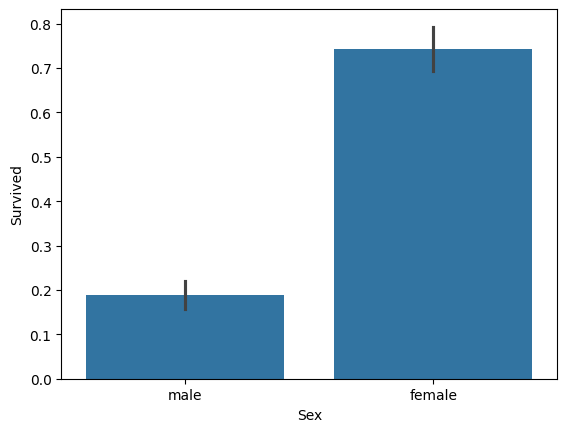

In [22]:
sns.barplot(x='Sex', y = 'Survived', data=titanic_df)

#### 객실 등급(부)에 따른 생존율

- 부를 측정할 수 있는 속성 → 객실 등급(Pclass): 일등실, 이등실, 삼등실
- 객실 등급만 보기보다 성별을 함께 고려하는 것이 더 효율적

<Axes: xlabel='Pclass', ylabel='Survived'>

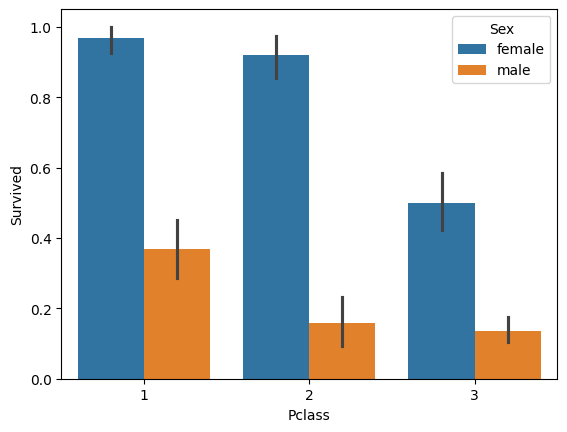

In [23]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)

- 여성: 일등실·이등실은 생존 확률 차이가 크지 않지만, 삼등실은 크게 떨어짐
- 남성: 일등실의 생존 확률이 이등실·삼등실보다 월등히 높음

#### 나이(Age)에 따른 생존율: 범위별로 카테고리 값을 할당

| 나이 범위 | 카테고리 |
|---|---|
| -1 이하 (오류 값) | Unknown |
| 0 ~ 5세 | Baby |
| 6 ~ 12세 | Child |
| 13 ~ 18세 | Teenager |
| 19 ~ 25세 | Student |
| 26 ~ 35세 | Young Adult |
| 36 ~ 60세 | Adult |
| 61세 이상 | Elderly |

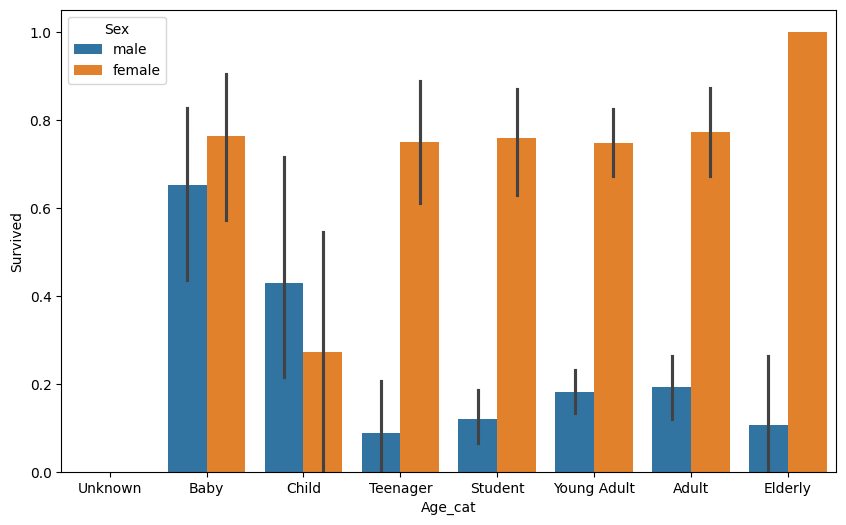

In [24]:
# 입력 age에 따라 구분 값을 반환하는 함수 설정. DataFrame의 apply lambda 식에 사용.
def get_category(age):
    cat = ''
    if age <= -1: cat = 'Unknown'
    elif age <= 5: cat = 'Baby'
    elif age <= 12: cat = 'Child'
    elif age <= 18: cat = 'Teenager'
    elif age <= 25: cat = 'Student'
    elif age <= 35: cat = 'Young Adult'
    elif age <= 60: cat = 'Adult'
    else : cat = 'Elderly'

    return cat

# 막대그래프의 크기 figure를 더 크게 설정
plt.figure(figsize=(10, 6))

# X축의 값을 순차적으로 표시하기 위한 설정
group_names = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']

# lambda 식에 위에서 생성한 get_category( ) 함수를 반환값으로 지정.
# get_category(X)는 입력값으로 'Age' 칼럼 값을 받아서 해당하는 cat 반환
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x : get_category(x))
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df, order=group_names)
titanic_df.drop('Age_cat', axis=1, inplace=True)

- 여자 Baby: 생존 확률이 비교적 높음
- 여자 Child: 다른 연령대에 비해 생존 확률이 낮음
- 여자 Elderly: 생존 확률이 매우 높음
- → Sex, Age, Pclass가 생존을 좌우하는 중요한 피처임을 확인

### 문자열 카테고리 피처 인코딩: 남아 있는 문자열 카테고리 피처를 숫자형 카테고리 피처로 변환
- 사이킷런의 `LabelEncoder`로 레이블 인코딩 적용
- 여러 칼럼을 한 번에 변환하기 위해 `encode_features()` 함수를 새로 생성

In [25]:
from sklearn.preprocessing import LabelEncoder

def encode_features(dataDF):
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder( )
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])

    return dataDF

titanic_df = encode_features(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


### 전처리 과정 함수화: 지금까지의 피처 가공 내역을 함수로 만들어 쉽게 재사용할 수 있도록 정리
- `transform_features()`: 전처리를 전체적으로 호출하는 함수
  - 내부 함수: Null 처리, 불필요한 피처 제거, 인코딩
- `drop_features(df)`: 불필요한 피처 제거
  - ML 알고리즘에 불필요한 단순 식별자 수준의 피처 → PassengerId, Name, Ticket 제거

In [26]:
# Null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 수행.
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

### 원본 데이터 재가공

  1. 원본 CSV 파일을 다시 로딩
  2. 레이블인 Survived 속성만 따로 분리 → 클래스 결정값 데이터 세트
  3. Survived 속성을 drop →
  피처 데이터 세트
  4. 피처 데이터 세트에 `transform_features()`를 적용해 데이터 가공

In [28]:
# 원본 데이터를 재로딩하고, 피처 데이터 세트와 레이블 데이터 세트 추출.
titanic_df = pd.read_csv('/content/train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df= titanic_df.drop('Survived', axis=1)

X_titanic_df = transform_features(X_titanic_df)

/tmp/ipykernel_1890/2674158776.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_1890/2674158776.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

학습 데이터 세트를 기반으로 `train_test_split()`을 이용해 별도의 테스트 데이터 세트 추출

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_titanic_df, y_titanic_df,
                                                  test_size=0.2, random_state=11)

### ML 알고리즘으로 생존자 예측

- 로지스틱 회귀: 강력한 분류 알고리즘

- 진행 방식
  - `train_test_split()`으로 나눈 학습 데이터로 학습(`fit`), 테스트 데이터로 예측(`predict`)
  - 성능 평가는 `accuracy_score()` 사용
- `solver='liblinear'`: 로지스틱 회귀의 최적화 알고리즘을 liblinear로 설정
  - 작은 데이터 세트의 이진 분류에서 성능이 약간 더 좋은 경향

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 결정트리, Random Forest, 로지스틱 회귀를 위한 사이킷런 Classifier 클래스 생성
dt_clf = DecisionTreeClassifier(random_state=11)
rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression(solver='liblinear')

# DecisionTreeClassifier 학습/예측/평가
dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
print('DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

# RandomForestClassifier 학습/예측/평가
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
print('RandomForestClassifier 정확도:{0:.4f}'.format(accuracy_score(y_test, rf_pred)))

# LogisticRegression 학습/예측/평가
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
print('LogisticRegression 정확도: {0:.4f}'.format(accuracy_score(y_test, lr_pred)))

DecisionTreeClassifier 정확도: 0.7877
RandomForestClassifier 정확도:0.8547
LogisticRegression 정확도: 0.8659


#### 알고리즘별 정확도 비교

- LogisticRegression의 정확도가 가장 높음
- 하지만 아직 최적화 작업을 하지 않았고 데이터 양도 충분하지 않아서, 어떤 알고리즘이 가장 좋다고 평가할 수는 없음

### 교차 검증으로 결정 트리 모델 평가

- 사이킷런 `model_selection` 패키지의 교차 검증 도구를 모두 사용
  - `KFold` 클래스
  - `cross_val_score()`
  - `GridSearchCV` 클래스

In [31]:
from sklearn.model_selection import KFold

def exec_kfold(clf, folds=5):
    # 폴드 세트를 5개인 KFold 객체를 생성, 폴드 수만큼 예측결과 저장을 위한  리스트 객체 생성.
    kfold = KFold(n_splits=folds)
    scores = []

    # KFold 교차 검증 수행.
    for iter_count, (train_index, test_index) in enumerate(kfold.split(X_titanic_df)):
        # X_titanic_df 데이터에서 교차 검증별로 학습과 검증 데이터를 가리키는 index 생성
        X_train, X_test = X_titanic_df.values[train_index], X_titanic_df.values[test_index]
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]
        # Classifier 학습, 예측, 정확도 계산
        clf.fit(X_train, y_train)
        predictions = clf.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)
        scores.append(accuracy)
        print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))

    # 5개 fold에서의 평균 정확도 계산.
    mean_score = np.mean(scores)
    print("평균 정확도: {0:.4f}".format(mean_score))
# exec_kfold 호출
exec_kfold(dt_clf, folds=5)

교차 검증 0 정확도: 0.7542
교차 검증 1 정확도: 0.7809
교차 검증 2 정확도: 0.7865
교차 검증 3 정확도: 0.7697
교차 검증 4 정확도: 0.8202
평균 정확도: 0.7823


In [32]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt_clf, X_titanic_df, y_titanic_df, cv=5)
for iter_count, accuracy in enumerate(scores):
    print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))

print("평균 정확도: {0:.4f}".format(np.mean(scores)))

교차 검증 0 정확도: 0.7430
교차 검증 1 정확도: 0.7753
교차 검증 2 정확도: 0.7921
교차 검증 3 정확도: 0.7865
교차 검증 4 정확도: 0.8427
평균 정확도: 0.7879


#### cross_val_score()와 KFold 결과 차이

- `cross_val_score()`와 KFold의 평균 정확도가 약간 다름
- 이유: `cross_val_score()`는 StratifiedKFold로 폴드 세트를 분할하기 때문

### GridSearchCV로 하이퍼 파라미터 튜닝

- `GridSearchCV`로 `DecisionTreeClassifier`의 최적 하이퍼 파라미터를 찾고 예측 성능 측정
- 설정
  - CV: 5개 폴드 세트
  - 변경할 하이퍼 파라미터: `max_depth`, `min_samples_split`, `min_samples_leaf`


In [33]:
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth':[2, 3, 5, 10],
              'min_samples_split':[2, 3, 5], 'min_samples_leaf':[1, 5, 8]}

grid_dclf = GridSearchCV(dt_clf, param_grid=parameters, scoring='accuracy', cv=5)
grid_dclf.fit(X_train, y_train)

print('GridSearchCV 최적 하이퍼 파라미터 :', grid_dclf.best_params_)
print('GridSearchCV 최고 정확도: {0:.4f}'.format(grid_dclf.best_score_))
best_dclf = grid_dclf.best_estimator_

# GridSearchCV의 최적 하이퍼 파라미터로 학습된 Estimator로 예측 및 평가 수행.
dpredictions = best_dclf.predict(X_test)
accuracy = accuracy_score(y_test, dpredictions)
print('테스트 세트에서의 DecisionTreeClassifier 정확도 : {0:.4f}'.format(accuracy))

GridSearchCV 최적 하이퍼 파라미터 : {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV 최고 정확도: 0.7992
테스트 세트에서의 DecisionTreeClassifier 정확도 : 0.8715


#### GridSearchCV 튜닝 결과

- 최적 하이퍼 파라미터: `max_depth=3`, `min_samples_leaf=5`, `min_samples_split=2`
- 이 값으로 학습한 DecisionTreeClassifier의 예측 정확도: 약 87.15%
  - 하이퍼 파라미터 변경 전(약 78.77%)보다 8% 이상 증가
- 주의: 일반적으로 튜닝만으로 이 정도 수준까지 오르기는 매우 어려움
  - 테스트 데이터 세트가 작아서 수치상으로 성능이 많이 오른 것처럼 보이는 것

## 07. 정리



### 사이킷런의 특징

- 파이썬 계열의 대표적인 머신러닝 패키지
  - 매우 많은 ML 알고리즘 제공
  - 쉽고 직관적인 API 프레임워크
  - 편리하고 다양한 지원 모듈
- 여러 개발 환경에서 오랜 기간 동안 안정성과 유용성이 검증됨



### 머신러닝 애플리케이션 구성

1. **데이터 전처리**: 데이터 가공 및 변환
2. **데이터 세트 분리**: 학습 데이터 / 테스트 데이터
3. **모델 학습**: 학습 데이터로 ML 알고리즘 적용
4. **예측**: 학습된 모델로 테스트 데이터 예측
5. **평가**: 예측값과 실제값을 비교해 모델 평가



### 데이터 전처리

- ML 알고리즘이 최적으로 수행되도록 데이터를 사전 처리하는 작업
  - **데이터 클렌징**: 오류 데이터 보정, 결손값(Null) 처리
  - **인코딩**: 레이블 인코딩, 원-핫 인코딩
  - **스케일링/정규화**



### 모델 평가와 교차 검증

- 모델은 학습 후 반드시 별도의 테스트 데이터 세트로 평가해야 함
- 테스트 데이터 건수가 부족하거나 고정된 테스트 데이터로 반복 학습·평가하면
  → 해당 테스트 데이터에만 치우친 빈약한 모델이 될 가능성이 높음
- 해결: 학습 데이터를 학습/검증 데이터로 구성된 여러 폴드 세트로 나눠 교차 검증수행
  - `KFold`, `StratifiedKFold`, `cross_val_score()`
  - 교차 검증으로 최적 하이퍼 파라미터를 찾는 `GridSearchCV`

